In [1]:
pip install transformers datasets torch scikit-learn pandas

In [3]:
import pandas as pd

fake = pd.read_csv("Fake.csv")
true = pd.read_csv("True.csv")

fake['label'] = 0
true['label'] = 1

df = pd.concat([fake, true])

print("Total rows:", len(df))
df.head()

Total rows: 44898


,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [4]:
df = df.sample(3000, random_state=42)
df = df[['text', 'label']]              # keep only needed columns

df.to_csv("dataset.csv", index=False)

print("New dataset size:", len(df))

New dataset size: 3000


In [5]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)   # remove links
    text = re.sub(r'[^a-zA-Z ]', '', text) # remove symbols
    return text

df['text'] = df['text'].apply(clean_text)

In [6]:
from sklearn.model_selection import train_test_split

texts = df['text'].tolist()
labels = df['label'].tolist()

train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42
)

In [7]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=128)
val_encodings = tokenizer(val_texts, truncation=True, padding=True, max_length=128)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [8]:
import torch

class Dataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = Dataset(train_encodings, train_labels)
val_dataset = Dataset(val_encodings, val_labels)

In [9]:
from transformers import BertForSequenceClassification

model = BertForSequenceClassification.from_pretrained('bert-base-uncased')
for param in model.bert.parameters():
    param.requires_grad = False

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [10]:
from transformers import Trainer, TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=10,
    logging_dir="./logs",
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [11]:
from sklearn.utils.class_weight import compute_class_weight
import torch
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=df['label']
)

class_weights = torch.tensor(class_weights, dtype=torch.float)

In [12]:
from transformers import Trainer
import torch.nn as nn

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        loss_fct = nn.CrossEntropyLoss(weight=class_weights.to(logits.device))
        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss

In [13]:
import torch
print(torch.cuda.is_available())

True


In [14]:
from transformers import Trainer

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
)

trainer.train()

Epoch,Training Loss,Validation Loss
1,0.660934,0.662239
2,0.653175,0.638204
3,0.650008,0.631007


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=900, training_loss=0.6567464505301581, metrics={'train_runtime': 76.6882, 'train_samples_per_second': 93.887, 'train_steps_per_second': 11.736, 'total_flos': 473599899648000.0, 'train_loss': 0.6567464505301581, 'epoch': 3.0})

In [15]:
predictions = trainer.predict(val_dataset)
preds = predictions.predictions.argmax(axis=1)

from sklearn.metrics import classification_report
print(classification_report(val_labels, preds))

              precision    recall  f1-score   support

           0       0.87      0.78      0.82       313
           1       0.78      0.87      0.82       287

    accuracy                           0.82       600
   macro avg       0.82      0.82      0.82       600
weighted avg       0.83      0.82      0.82       600



In [16]:
model.save_pretrained("bert_model")
tokenizer.save_pretrained("bert_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('bert_model/tokenizer_config.json', 'bert_model/tokenizer.json')

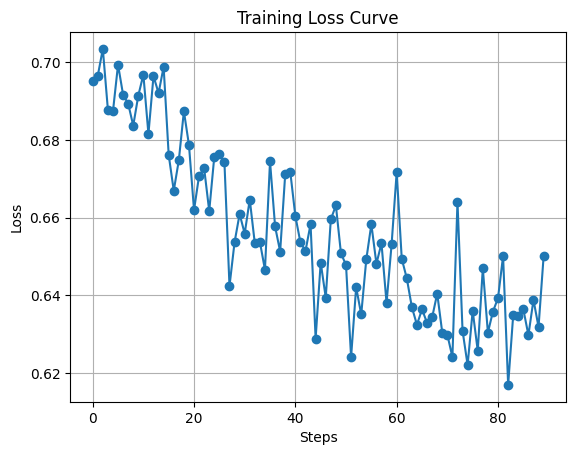

In [17]:
import matplotlib.pyplot as plt

logs = trainer.state.log_history

losses = [x["loss"] for x in logs if "loss" in x]
steps = list(range(len(losses)))

plt.plot(steps, losses, marker='o')
plt.title("Training Loss Curve")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.grid()
plt.show()

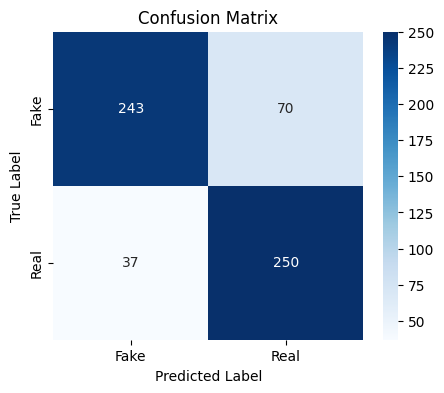

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Recompute predictions
predictions = trainer.predict(val_dataset)
preds = predictions.predictions.argmax(axis=1)

# Get true labels
true_labels = val_labels

# Confusion matrix
cm = confusion_matrix(true_labels, preds)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake', 'Real'],
            yticklabels=['Fake', 'Real'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.savefig("confusion_matrix.png")
plt.show()

In [19]:
print(trainer.state.log_history)

[{'loss': 0.6950853824615478, 'grad_norm': 4.114949703216553, 'learning_rate': 4.9500000000000004e-05, 'epoch': 0.03333333333333333, 'step': 10}, {'loss': 0.696505355834961, 'grad_norm': 4.273711204528809, 'learning_rate': 4.894444444444445e-05, 'epoch': 0.06666666666666667, 'step': 20}, {'loss': 0.7034297466278077, 'grad_norm': 3.433368682861328, 'learning_rate': 4.838888888888889e-05, 'epoch': 0.1, 'step': 30}, {'loss': 0.6877661228179932, 'grad_norm': 1.6901661157608032, 'learning_rate': 4.7833333333333335e-05, 'epoch': 0.13333333333333333, 'step': 40}, {'loss': 0.687372875213623, 'grad_norm': 2.068164825439453, 'learning_rate': 4.727777777777778e-05, 'epoch': 0.16666666666666666, 'step': 50}, {'loss': 0.6993632793426514, 'grad_norm': 3.977588415145874, 'learning_rate': 4.672222222222222e-05, 'epoch': 0.2, 'step': 60}, {'loss': 0.6916170597076416, 'grad_norm': 3.0049943923950195, 'learning_rate': 4.6166666666666666e-05, 'epoch': 0.23333333333333334, 'step': 70}, {'loss': 0.689349603

In [20]:
def predict_news(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=128)
    # Move inputs to the same device as the model
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    outputs = model(**inputs)
    logits = outputs.logits
    predicted_class = logits.argmax().item()

    return "Real News" if predicted_class == 1 else "Fake News"

In [21]:
print(predict_news("Government announces new policy"))
print(predict_news("Aliens landed in India yesterday"))

Fake News
Fake News


In [22]:
import shutil
shutil.make_archive("bert_model", 'zip', "bert_model")

'/content/bert_model.zip'

In [23]:
from google.colab import files
files.download("bert_model.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>